In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('../Data/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [27]:
df.shape

(768, 9)

In [28]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.isnull().sum().sum()

np.int64(0)

In [33]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [34]:
X = df.drop('Outcome', axis=1)

y = df['Outcome'] 

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
X_train, X_test, y_train , y_test = train_test_split(
    X,y, test_size=.20 ,random_state=42
)

print('shape of X_train', X_train.shape)
print('Shape of X_test',X_test.shape)
print('shape of y_train',y_train.shape)
print('shape of y_test',y_test.shape)


shape of X_train (614, 8)
Shape of X_test (154, 8)
shape of y_train (614,)
shape of y_test (154,)


In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.fit_transform(X_test)

In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [40]:
model = Sequential([
    Dense(16, activation="relu", input_shape=(8,)),
    Dense(8, activation='relu'),
    Dense(1, activation="sigmoid")
])

d:\diabetes-prediction-deep-learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

In [44]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4134 - loss: 0.7674 - val_accuracy: 0.3740 - val_loss: 0.7276
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5336 - loss: 0.7012 - val_accuracy: 0.5854 - val_loss: 0.6807
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6578 - loss: 0.6504 - val_accuracy: 0.6667 - val_loss: 0.6445
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7108 - loss: 0.6129 - val_accuracy: 0.7154 - val_loss: 0.6165
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7454 - loss: 0.5848 - val_accuracy: 0.7317 - val_loss: 0.5932
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7475 - loss: 0.5617 - val_accuracy: 0.7398 - val_loss: 0.5751
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7597 - loss: 0.5437 - val_accuracy: 0.7561 - val_loss: 0.5590
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7699 - loss: 0.5298 - val_accuracy: 0.7

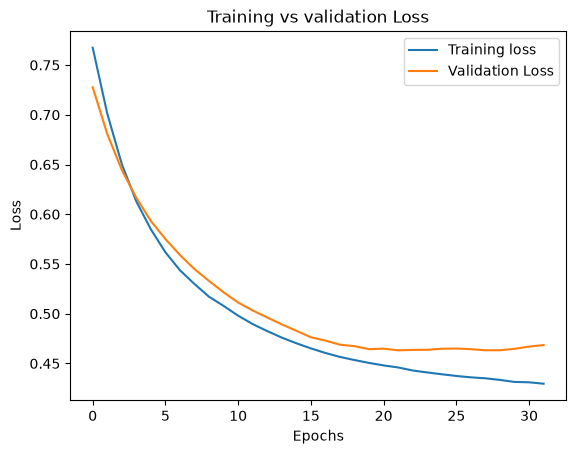

In [46]:
plt.Figure(figsize=(8,6))

plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs validation Loss")
plt.xlabel("Epochs")
plt.ylabel('Loss')

plt.legend()

plt.show()

"The model is learning well because both the training loss and validation loss decrease steadily. Toward the later epochs, the validation loss begins to plateau and increase slightly while the training loss continues to decrease, indicating the beginning of overfitting. However, the gap between the curves is small, so the model is still generalizing reasonably well."

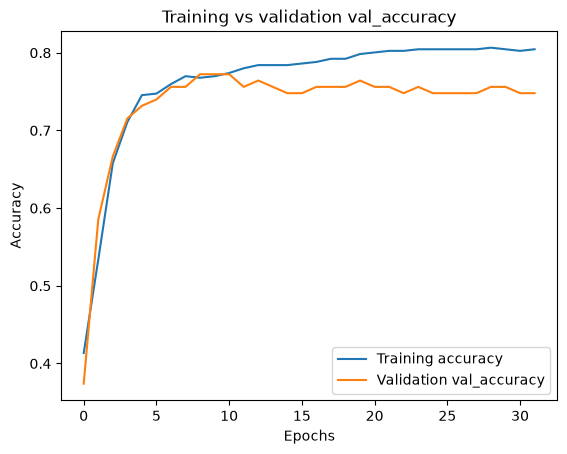

In [48]:
plt.Figure(figsize=(8,6))

plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation val_accuracy')

plt.title("Training vs validation val_accuracy")
plt.xlabel("Epochs")
plt.ylabel('Accuracy')

plt.legend()

plt.show()

In [49]:
test_loss, test_accuracy = model.evaluate(X_test,y_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7532 - loss: 0.5080


In [50]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.507986843585968
Test Accuracy: 0.7532467246055603


In [51]:
model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


array([[0.36725464],
       [0.09921709],
       [0.10260669],
       [0.25616744],
       [0.37945533],
       [0.6869684 ],
       [0.01383563],
       [0.69066226],
       [0.5813843 ],
       [0.6679385 ],
       [0.36358204],
       [0.7711756 ],
       [0.21317434],
       [0.45854443],
       [0.10586598],
       [0.42383596],
       [0.09598678],
       [0.08314661],
       [0.8233706 ],
       [0.500869  ],
       [0.17556395],
       [0.05061014],
       [0.55719537],
       [0.04748875],
       [0.5461357 ],
       [0.709401  ],
       [0.15516329],
       [0.03499861],
       [0.07737306],
       [0.13190778],
       [0.7474546 ],
       [0.73738897],
       [0.6664697 ],
       [0.84406936],
       [0.66168475],
       [0.67660034],
       [0.8583019 ],
       [0.36541575],
       [0.3665976 ],
       [0.65297306],
       [0.07600991],
       [0.50675994],
       [0.67315257],
       [0.19107425],
       [0.06335387],
       [0.54405916],
       [0.7402123 ],
       [0.203

In [52]:
y_pred_prob = model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [55]:
y_pred_prob

array([[0.36725464],
       [0.09921709],
       [0.10260669],
       [0.25616744],
       [0.37945533],
       [0.6869684 ],
       [0.01383563],
       [0.69066226],
       [0.5813843 ],
       [0.6679385 ],
       [0.36358204],
       [0.7711756 ],
       [0.21317434],
       [0.45854443],
       [0.10586598],
       [0.42383596],
       [0.09598678],
       [0.08314661],
       [0.8233706 ],
       [0.500869  ],
       [0.17556395],
       [0.05061014],
       [0.55719537],
       [0.04748875],
       [0.5461357 ],
       [0.709401  ],
       [0.15516329],
       [0.03499861],
       [0.07737306],
       [0.13190778],
       [0.7474546 ],
       [0.73738897],
       [0.6664697 ],
       [0.84406936],
       [0.66168475],
       [0.67660034],
       [0.8583019 ],
       [0.36541575],
       [0.3665976 ],
       [0.65297306],
       [0.07600991],
       [0.50675994],
       [0.67315257],
       [0.19107425],
       [0.06335387],
       [0.54405916],
       [0.7402123 ],
       [0.203

In [53]:
y_pred = (y_pred_prob > .50).astype(int)

In [54]:
y_pred

array([[0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
    

In [56]:
from sklearn.metrics import confusion_matrix

In [57]:
print(confusion_matrix(y_test,y_pred))

[[79 20]
 [18 37]]


# Step 13 - Confusion Matrix

After making predictions, we compare them with the actual values using a **Confusion Matrix**.

```python
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)
```

Output:

```text
[[79 20]
 [18 37]]
```

---

## Understanding the Confusion Matrix

```
                    Predicted

                 No         Yes

Actual No        79          20

Actual Yes       18          37
```

Every value tells a different story.

### 1. True Negative (TN)

```
79
```

The patient **did not have diabetes**, and the model correctly predicted **No Diabetes**.

✅ Correct prediction.

---

### 2. False Positive (FP)

```
20
```

The patient **did not have diabetes**, but the model predicted **Diabetes**.

❌ Incorrect prediction.

Also called a **False Alarm**.

---

### 3. False Negative (FN)

```
18
```

The patient **actually had diabetes**, but the model predicted **No Diabetes**.

❌ Incorrect prediction.

This is usually the **most dangerous mistake** in medical diagnosis because a sick patient is classified as healthy.

---

### 4. True Positive (TP)

```
37
```

The patient **had diabetes**, and the model correctly predicted **Diabetes**.

✅ Correct prediction.

---

## Summary

| Actual | Predicted | Result |
|---------|-----------|--------|
| No Diabetes | No Diabetes | True Negative (79) ✅ |
| No Diabetes | Diabetes | False Positive (20) ❌ |
| Diabetes | No Diabetes | False Negative (18) ❌ |
| Diabetes | Diabetes | True Positive (37) ✅ |

---

## Total Predictions

```
79 + 20 + 18 + 37 = 154
```

This matches the size of our test dataset.

---

## Model Performance

Correct Predictions:

```
79 + 37 = 116
```

Incorrect Predictions:

```
20 + 18 = 38
```

Accuracy:

```
116 / 154 ≈ 75.3%
```

This matches the test accuracy we obtained using:

```python
model.evaluate(X_test, y_test)
```

---


In [58]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



# Step 14 - Classification Report

After generating predictions, we evaluate the model in more detail using the **Classification Report**.

```python
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
```

Output:

```text
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154
```

---

# Understanding Each Column

## Precision

Precision answers the question:

> **Out of all the patients the model predicted as diabetic, how many actually had diabetes?**

Formula:

```
Precision = TP / (TP + FP)
```

For Class **1 (Diabetes):**

```
Precision = 37 / (37 + 20)

= 37 / 57

≈ 0.65
```

This means:

> When the model predicts **Diabetes**, it is correct about **65%** of the time.

---

## Recall

Recall answers:

> **Out of all the patients who actually had diabetes, how many did the model successfully identify?**

Formula:

```
Recall = TP / (TP + FN)
```

For Class **1:**

```
Recall = 37 / (37 + 18)

= 37 / 55

≈ 0.67
```

Meaning:

> The model successfully detected **67%** of diabetic patients.

---

## F1-Score

The F1-score combines Precision and Recall into a single metric.

Formula:

```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```

For Class **1**, the F1-score is:

```
0.66
```

A higher F1-score means a better balance between Precision and Recall.

---

## Support

Support is simply:

> **The number of actual samples belonging to each class.**

Here:

```
Class 0 → 99 patients

Class 1 → 55 patients
```

Total:

```
99 + 55 = 154
```

which matches the size of our test dataset.

---

# Understanding the Results

### Class 0 (No Diabetes)

Precision:

```
0.81
```

When the model predicts **No Diabetes**, it is correct **81%** of the time.

Recall:

```
0.80
```

It correctly identifies **80%** of all non-diabetic patients.

This class performs well.

---

### Class 1 (Diabetes)

Precision:

```
0.65
```

Only **65%** of patients predicted as diabetic actually have diabetes.

Recall:

```
0.67
```

The model detects **67%** of all diabetic patients.

This is lower than Class 0 because diabetes cases are generally harder to classify.

---

# Macro Average

```
Precision : 0.73

Recall : 0.74

F1-score : 0.73
```

Macro Average calculates the metric for each class independently and then takes the simple average.

Each class is treated equally, regardless of how many samples it has.

---

# Weighted Average

```
Precision : 0.76

Recall : 0.75

F1-score : 0.75
```

Weighted Average also averages the metrics, but it considers the number of samples (support) in each class.

Since Class 0 has more samples (99 vs 55), it contributes more to the final weighted score.

---

# Overall Analysis

✅ Accuracy: **75%**

✅ Strong performance for **Class 0**

✅ Reasonable performance for **Class 1**

✅ Recall of **67%** means the model identifies about two-thirds of diabetic patients.

Overall, the model performs reasonably well for a simple ANN trained on the Pima Indians Diabetes dataset.

In [59]:
from sklearn.metrics import roc_auc_score,roc_curve

In [60]:
auc = roc_auc_score(y_test, y_pred_prob)

In [61]:
print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.8128558310376492


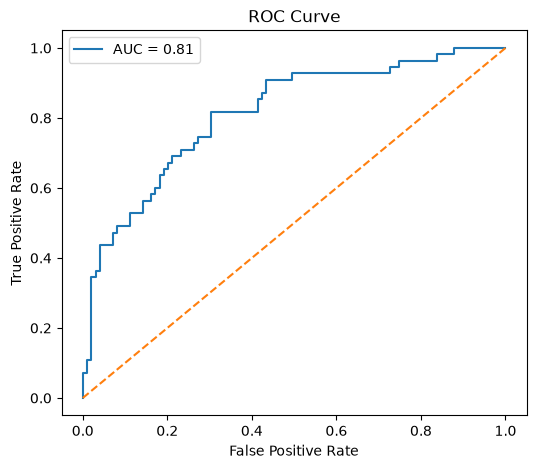

In [62]:


fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()